In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, dataset
from torchmetrics import F1Score
from torchvision import transforms
from torchvision.transforms import ToTensor, Resize, Compose, Normalize, Pad
from torchvision import models
from torchvision import datasets
from collections import Counter, defaultdict
from PIL import Image
import random
import gc

In [2]:
def seed(seed = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)

In [3]:
seed()

In [4]:
gc.collect()

82

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Подготовка данных

In [6]:
data = datasets.ImageFolder("train/train")

In [13]:
data_train, data_test = train_test_split(data, test_size= 0.2, random_state = 42, shuffle=True)

In [14]:
len(data), len(data_train), len(data_test)

(15561, 12448, 3113)

Counter({(640, 480): 6269, (640, 360): 2161, (360, 480): 809, (640, 427): 444, (640, 384): 321, (640, 478): 267, (270, 480): 177, (604, 453): 141, (640, 477): 132, (640, 361): 130, (480, 480): 124, (640, 359): 118, (640, 426): 108, (640, 385): 75, (640, 383): 50, (640, 424): 49, (639, 480): 43, (640, 362): 42, (288, 480): 37, (640, 425): 32, (358, 480): 31, (640, 479): 29, (604, 340): 24, (359, 480): 22, (604, 451): 22, (640, 429): 19, (640, 474): 16, (640, 428): 15, (271, 480): 15, (640, 475): 15, (480, 360): 12, (361, 480): 12, (600, 450): 11, (640, 438): 10, (289, 480): 10, (631, 480): 9, (640, 430): 9, (604, 452): 9, (604, 339): 8, (640, 358): 8, (640, 440): 8, (640, 423): 7, (604, 341): 6, (604, 362): 6, (640, 436): 5, (480, 320): 5, (320, 240): 5, (269, 480): 5, (555, 480): 5, (640, 439): 5, (604, 403): 4, (640, 435): 4, (640, 365): 4, (600, 337): 4, (640, 377): 4, (320, 480): 4, (640, 380): 4, (640, 418): 4, (640, 454): 4, (640, 417): 4, (640, 382): 4, (640, 393): 4, (601, 480):

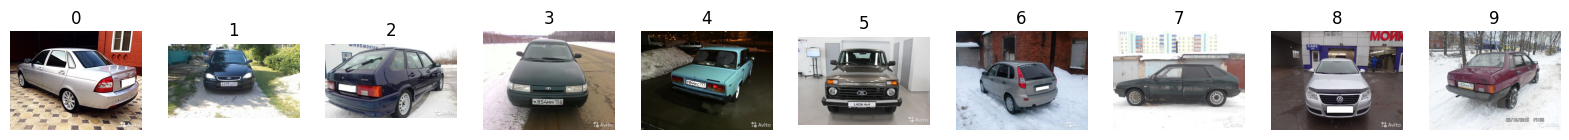

In [15]:
labels_list,  size_list, labels_count  = [], [], []
labels_dict = {}
for i in range(len(data_train)):
    size_list.append(data_train[i][0].size)
    labels_count.append(data_train[i][1])
    if data_train[i][1] not in labels_list:
        labels_list.append(data_train[i][1])
        labels_dict[data_train[i][1]] = data_train[i][0]
size_count_dict = Counter(size_list)
labels_count_dict = Counter(labels_count)
fig, axs = plt.subplots(1, len(labels_dict), figsize = (20,5))
print(size_count_dict, labels_count_dict)
for k, v in labels_dict.items():
    axs.flat[k].imshow(v)
    axs.flat[k].axis("off")
    axs.flat[k].set_title(k)

In [16]:
dict_images = {}
aug = [transforms.RandomHorizontalFlip(p=1), transforms.RandomRotation(degrees=10), transforms.ColorJitter(0.3, 0.3 ,0.3)]
train_data_aug = []
for k in labels_count_dict.keys():
    dict_images[k] = []
for image, label in data_train:
    dict_images[label].append(image)
for k in dict_images.keys():
    print(k, len(dict_images[k]))
for k, v in dict_images.items():
    while len(dict_images[k])<1600:
        a = random.choice(aug)
        flip = a
        b = random.choice(v)
        new_image = a(b)
        dict_images[k].append(new_image)
    for i in range(len(dict_images[k])):
        train_data_aug.append((dict_images[k][i],k))
for k in dict_images.keys():
    print(k, len(dict_images[k]))
random.shuffle(train_data_aug)    
print(f"длина итогового тренировочного датасета: {len(train_data_aug)}")

3 1214
1 1587
2 1151
9 1007
6 1388
0 1295
4 1127
8 1423
7 969
5 1287
3 1600
1 1600
2 1600
9 1600
6 1600
0 1600
4 1600
8 1600
7 1600
5 1600
длина итогового тренировочного датасета: 16000


In [17]:

def transformering(data, w, h, w_crop, h_crop):
    data_transform = []
    for i in range(len(data)):
        if not isinstance((data[i][0]),Image.Image):
            print (f"неподходящий тип данных, {type(data[i][0])}")
            continue
        else:
            w1,h1 = data[i][0].size
            pad = Pad(
                padding=(round((w-w1)/2), round((h-h1)/2), round((w-w1)/2),  round((h-h1)/2)),
                fill=(128,128,128)
            )
            resize = Resize((h,w))
            crop = transforms.CenterCrop((h_crop,w_crop))
            resize2 = Resize((h_crop//2, w_crop//2))
            

            image_pad = pad(data[i][0])
            image_pad = resize(image_pad)
            image_pad_crop = crop(image_pad)
            image_pad_crop = resize2(image_pad_crop)
            data_transform.append((image_pad_crop, data[i][1]))

    return data_transform


In [18]:

data_train_transform = transformering(train_data_aug, 640, 480, 480, 256)
data_test_transform = transformering(data_test, 640,480,480,256)

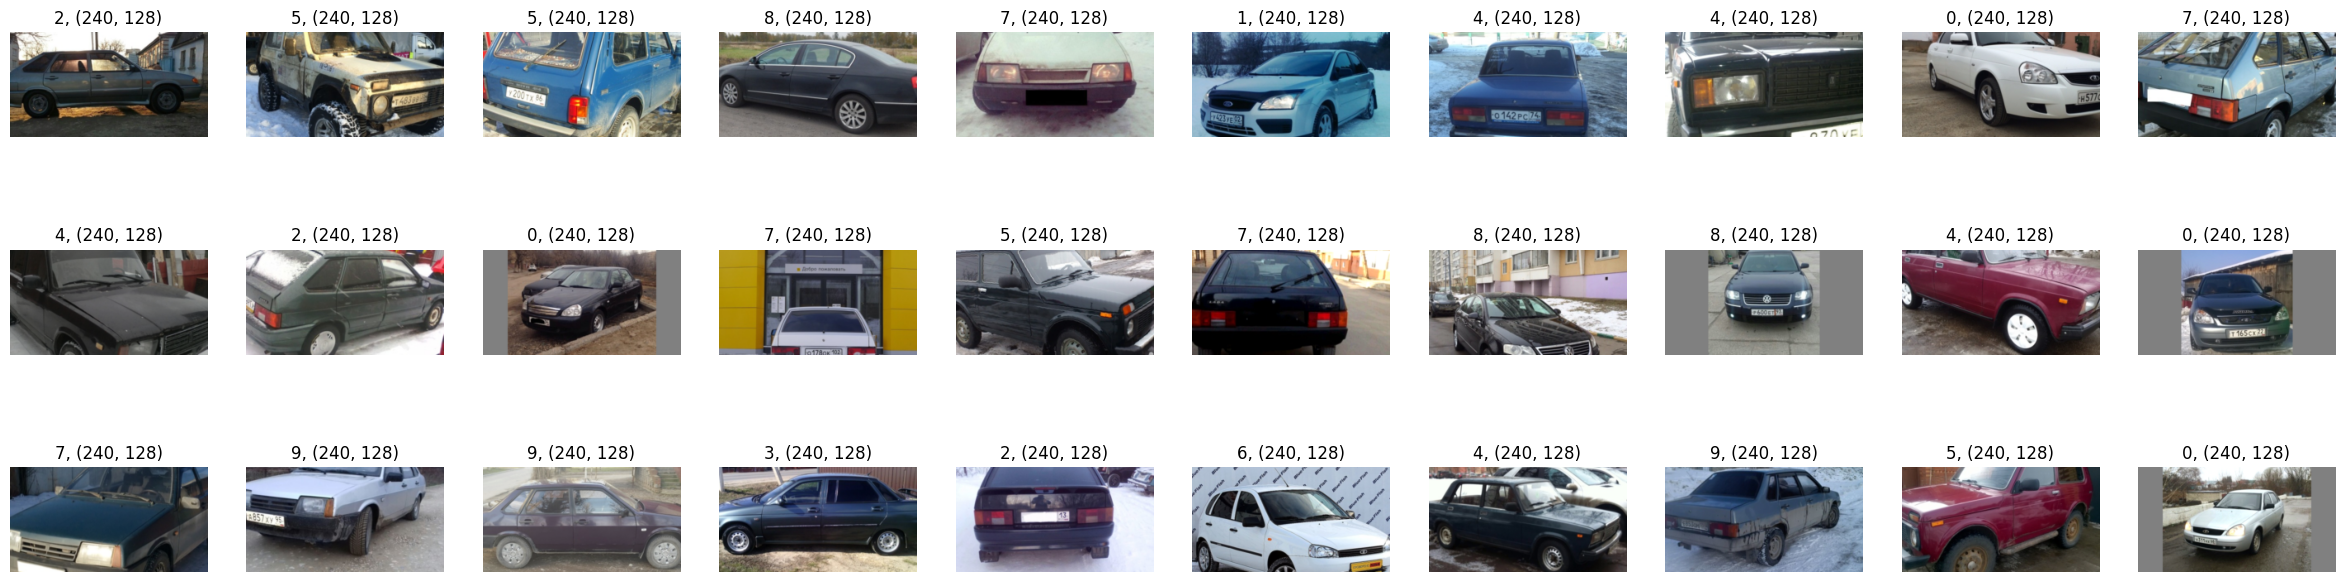

In [19]:
fig, axs = plt.subplots(3,10, figsize = (30,8))
for i in range(3*10):
    a = np.random.randint(len(data_train_transform))
    axs.flat[i].imshow(data_train_transform[a][0])
    axs.flat[i].axis("off")
    axs.flat[i].set_title(f"{data_train_transform[a][1]}, {data_train_transform[a][0].size}")

In [20]:
class CarDataset():
    def __init__(self, data, transform, is_train = True):
        self.data = data
        self.transform = transform
        self.is_train = is_train

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        image = self.data[i][0]
        image_transformed = self.transform(image)
        if self.is_train:
            label = self.data[i][1]
            return image_transformed, label
        else:
            return image_transformed


In [21]:
transform = Compose([
    ToTensor(),
    Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])
train_dataset = CarDataset(data_train_transform, transform=transform, is_train=True)
test_dataset = CarDataset(data_test_transform, transform=transform, is_train = True)


In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [23]:
for i in range(10):
    a = random.randint(0, len(train_loader.dataset))
    b = random.randint(0, len(test_loader.dataset))
    print(f" для трейна {train_loader.dataset[a][0].shape}\t для теста {test_loader.dataset[b][0].shape}")

 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])
 для трейна torch.Size([3, 128, 240])	 для теста torch.Size([3, 128, 240])


# Обучение и выбор лучше моей модели

In [24]:
class CNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels = 128, out_channels=128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.AdaptiveAvgPool2d(2),
            nn.Flatten(),
            nn.Linear(in_features=256*2*2, out_features=512),
            nn.Dropout(0.4),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=512, out_features=256),
            nn.Dropout(0.4),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=256, out_features=n_classes)
        )


    def forward(self, x):
        return self.model(x)
        

In [25]:
def modeling(model,train_loader, test_loader, loss_f, optimizer, n_epoch, name):
    F1_best, n_epoch, iterations = 0, 0, 0
    acc_train_list, acc_test_list, avg_train_loss_list, avg_test_loss_list, F1_test_list = [],[],[],[],[]
    for epoch in range(n_epochs):
        f1 = F1Score(task="multiclass", num_classes=10, average="macro").to(device)
        model.train()
        correct = 0
        sum_loss = 0
        for step, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = loss_f(output, target)
            sum_loss += loss.item()
            loss.backward()
            optimizer.step()
            pred = output.argmax(dim = 1)
            correct += pred.eq(target.view_as(pred)).sum().item()
        acc_train = correct/len(train_loader.dataset)
        avg_loss = sum_loss/len(train_loader)
        acc_train_list.append(acc_train)
        avg_train_loss_list.append(avg_loss)
        print(f"для эпохи {epoch+1} train_accuracy: {acc_train: .5f}, loss: {avg_loss: .5f}")

        model.eval()
        correct = 0
        sum_loss_test = 0
        for step, (data, target) in enumerate(test_loader):
            data, target = data.to(device), target.to(device)
            with torch.no_grad():
                output = model(data)
                loss = loss_f(output, target)
                sum_loss_test += loss.item()
                pred = output.argmax(dim=1)
                correct +=pred.eq(target.view_as(pred)).sum().item()
                f1.update(pred, target)
        acc_test = correct/len(test_loader.dataset)
        avg_loss_test = sum_loss_test/len(test_loader)
        F1 = f1.compute()
        acc_test_list.append(acc_test)
        avg_test_loss_list.append(avg_loss_test)
        F1_test_list.append(F1.item())
        print(f" test_accuracy: {acc_test: .5f}, loss_test: {avg_loss_test: .5f}, f1_score:{F1:.3f}")
        if F1_best<F1:
            F1_best = F1
            n_epoch = epoch
            torch.save(model, f"best_model_{name}.pth")
            iterations = 0
        else:
            iterations +=1
        if iterations >3:
            print(f"началось переобучение\nлучшее значение метрики f1_score: {F1_best: .4f} достигнуто в {n_epoch+1} эпохе")
            break
    return acc_train_list, acc_test_list, avg_train_loss_list, avg_test_loss_list, F1_test_list
            
        

In [26]:
model = CNN(10)
model = model.to(device)
loss_f = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
n_epochs = 200

In [27]:
torch.cuda.empty_cache()

In [28]:
acc_train_list, acc_test_list, avg_train_loss_list, avg_test_loss_list, F1_test_list = modeling(model, train_loader, test_loader, loss_f, optimizer, n_epochs, name="CNN")

для эпохи 1 train_accuracy:  0.14325, loss:  2.24813
 test_accuracy:  0.17989, loss_test:  2.15312, f1_score:0.118
для эпохи 2 train_accuracy:  0.21656, loss:  2.11094
 test_accuracy:  0.27658, loss_test:  1.97175, f1_score:0.256
для эпохи 3 train_accuracy:  0.30806, loss:  1.86498
 test_accuracy:  0.35882, loss_test:  1.74746, f1_score:0.308
для эпохи 4 train_accuracy:  0.39937, loss:  1.60243
 test_accuracy:  0.43367, loss_test:  1.53646, f1_score:0.415
для эпохи 5 train_accuracy:  0.48150, loss:  1.38246
 test_accuracy:  0.42820, loss_test:  1.54689, f1_score:0.388
для эпохи 6 train_accuracy:  0.55819, loss:  1.18263
 test_accuracy:  0.58593, loss_test:  1.12812, f1_score:0.570
для эпохи 7 train_accuracy:  0.61231, loss:  1.04379
 test_accuracy:  0.57758, loss_test:  1.14021, f1_score:0.548
для эпохи 8 train_accuracy:  0.65969, loss:  0.90086
 test_accuracy:  0.68230, loss_test:  0.85627, f1_score:0.673
для эпохи 9 train_accuracy:  0.69506, loss:  0.79196
 test_accuracy:  0.63733, l

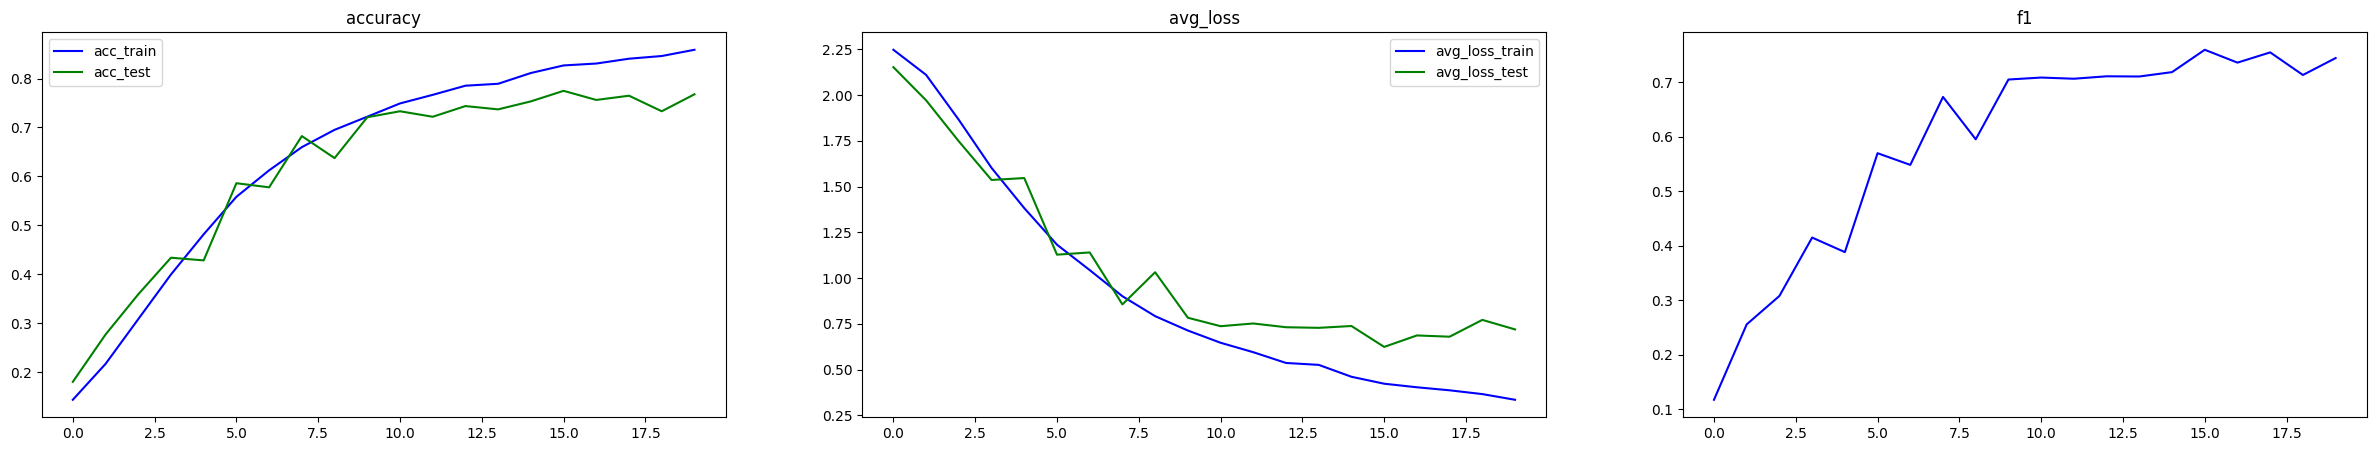

In [29]:
fig,axs = plt.subplots(1, 3, figsize = (30,5))

axs.flat[0].plot(range(len(acc_train_list)), acc_train_list, color = "blue", label = "acc_train")
axs.flat[0].plot(range(len(acc_test_list)), acc_test_list, color = "green", label = "acc_test")
axs.flat[0].legend()
axs.flat[0].set_title("accuracy")

axs.flat[1].plot(range(len(avg_train_loss_list)), avg_train_loss_list, color = "blue", label = "avg_loss_train")
axs.flat[1].plot(range(len(avg_test_loss_list)), avg_test_loss_list, color = "green", label = "avg_loss_test")
axs.flat[1].legend()
axs.flat[1].set_title("avg_loss")

axs.flat[2].plot(range(len(F1_test_list)), F1_test_list, color = "blue", label = "F1_test")
axs.flat[2].set_title("f1");
                 

# Загрузка и выбор лучше предобученной модели

In [30]:
model1 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

In [31]:
model1.classifier[1]

Linear(in_features=1280, out_features=1000, bias=True)

In [32]:
model1.classifier[1]= nn.Linear(model1.classifier[1].in_features, 10)
model1 = model1.to(device)

In [33]:
loss_f = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr = 1e-4)
n_epochs = 200

In [34]:
acc_train_list1, acc_test_list1, avg_train_loss_list1, avg_test_loss_list1, F1_test_list1 = modeling(model1, train_loader, test_loader, loss_f, optimizer1, n_epochs, name = "efficientnet_b0")

для эпохи 1 train_accuracy:  0.67744, loss:  0.98415
 test_accuracy:  0.88564, loss_test:  0.31715, f1_score:0.874
для эпохи 2 train_accuracy:  0.91287, loss:  0.25496
 test_accuracy:  0.91455, loss_test:  0.23357, f1_score:0.905
для эпохи 3 train_accuracy:  0.95462, loss:  0.13604
 test_accuracy:  0.91744, loss_test:  0.22807, f1_score:0.908
для эпохи 4 train_accuracy:  0.97144, loss:  0.08789
 test_accuracy:  0.92162, loss_test:  0.25403, f1_score:0.910
для эпохи 5 train_accuracy:  0.98044, loss:  0.06008
 test_accuracy:  0.92965, loss_test:  0.26067, f1_score:0.919
для эпохи 6 train_accuracy:  0.98531, loss:  0.04587
 test_accuracy:  0.92740, loss_test:  0.26831, f1_score:0.917
для эпохи 7 train_accuracy:  0.98806, loss:  0.03754
 test_accuracy:  0.92580, loss_test:  0.29147, f1_score:0.915
для эпохи 8 train_accuracy:  0.98975, loss:  0.03301
 test_accuracy:  0.92933, loss_test:  0.30706, f1_score:0.919
для эпохи 9 train_accuracy:  0.99138, loss:  0.02832
 test_accuracy:  0.92804, l

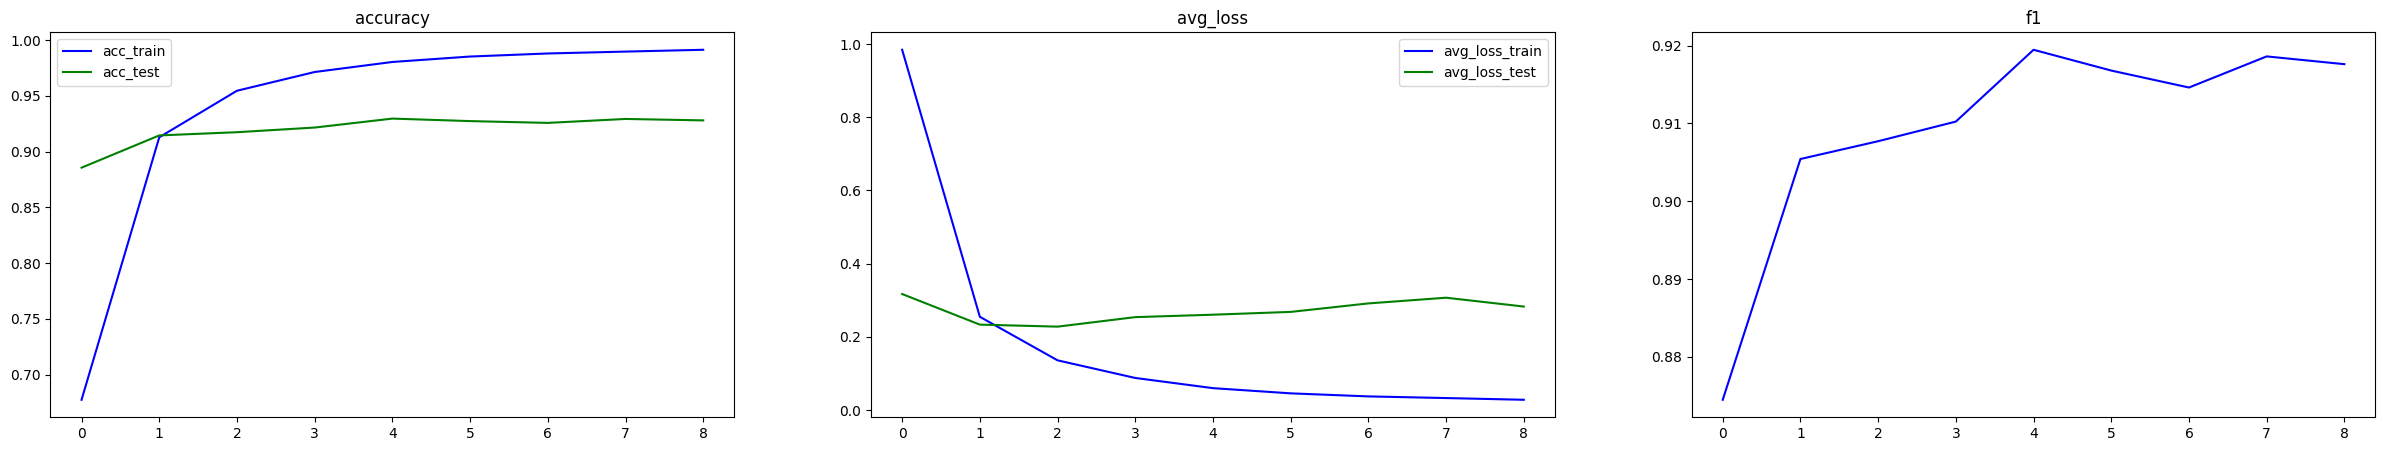

In [35]:
fig,axs = plt.subplots(1, 3, figsize = (30,5))

axs.flat[0].plot(range(len(acc_train_list1)), acc_train_list1, color = "blue", label = "acc_train")
axs.flat[0].plot(range(len(acc_test_list1)), acc_test_list1, color = "green", label = "acc_test")
axs.flat[0].legend()
axs.flat[0].set_title("accuracy")

axs.flat[1].plot(range(len(avg_train_loss_list1)), avg_train_loss_list1, color = "blue", label = "avg_loss_train")
axs.flat[1].plot(range(len(avg_test_loss_list1)), avg_test_loss_list1, color = "green", label = "avg_loss_test")
axs.flat[1].legend()
axs.flat[1].set_title("avg_loss")

axs.flat[2].plot(range(len(F1_test_list1)), F1_test_list1, color = "blue", label = "F1_test")
axs.flat[2].set_title("f1");

# Предсказания обоих моделей на валидационной выборке

In [63]:
val_data = datasets.ImageFolder("test")

In [64]:
val_data.imgs[0][0].split("\\")[-1]

'293307.jpg'

In [65]:
df_test = pd.read_csv("sample-submission.csv")
df_test.shape

(6675, 2)

In [66]:
df_test.head()

,Id,Category
0,305108.jpg,0
1,295075.jpg,0
2,31197.jpg,0
3,93598.jpg,0
4,87877.jpg,0


In [67]:
df_test["Category"].nunique()

1

In [68]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6675 entries, 0 to 6674
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Id        6675 non-null   object
 1   Category  6675 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 104.4+ KB


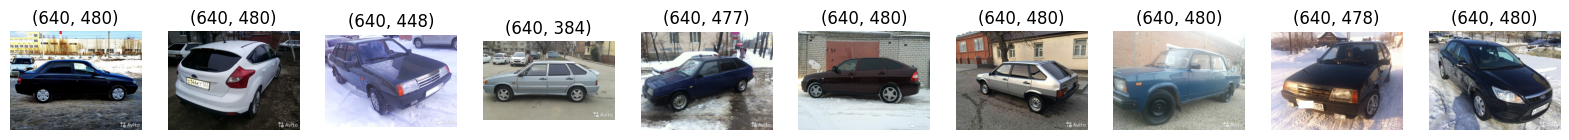

In [69]:
a = np.random.choice(range(len(val_data)),size = 10, replace = None)
fig, axs = plt.subplots(1, 10, figsize =(20, 5))
for i, image in enumerate(a):
    axs.flat[i].imshow(data_test[image][0])
    axs.flat[i].axis("off")
    axs.flat[i].set_title(data_test[image][0].size)

In [70]:
val_transform = transformering(val_data, 640, 480, 480, 256)
val_dataset = CarDataset(val_transform, transform=transform, is_train=False)
val_loader = DataLoader(val_dataset, batch_size=32)

In [71]:
len(val_transform)

6675

In [74]:
len(val_dataset)==len(df_test)

True

In [75]:
model_val_CNN =torch.load("best_model_CNN.pth", weights_only=False)
model_val_ef =torch.load("best_model_efficientnet_b0.pth", weights_only=False)
model_val_CNN = model_val_CNN.to(device)
model_val_ef = model_val_ef.to(device)

In [76]:
models = {"CNN":model_val_CNN, "EF" : model_val_ef}
df_total = df_test.copy()
for k,v  in models.items():
    v.eval()
    predictions= []
    for _, data in enumerate(val_loader):
        data = data.to(device)
        with torch.no_grad():
            output = v(data)
            pred = output.argmax(dim=1).cpu().numpy()
            predictions.extend(pred)
    df_pred = pd.DataFrame({"Id":[val_data.imgs[i][0].split("\\")[-1] for i in range(len(predictions))], f"pred_{k}" : [predictions[i] for i in range(len(predictions))]})
    df_total = df_total.merge(df_pred, on = "Id", how = "inner")
df_total

,Id,Category,pred_CNN,pred_EF
0,305108.jpg,0,7,7
1,295075.jpg,0,6,6
2,31197.jpg,0,4,4
3,93598.jpg,0,9,9
4,87877.jpg,0,7,9
...,...,...,...,...
6670,70330.jpg,0,4,4
6671,99227.jpg,0,9,9
6672,49915.jpg,0,1,1
6673,47272.jpg,0,3,3


In [79]:
df_total.to_csv("total_predictions.csv", index=False)